# FreeSurfer
## Cortical surface reconstruction and subcortical segmentation with `recon-all`

**Author**: Steffen Bollmann, Michèle Masson-Trottier

**Original date**: 17 Oct 2024

**Last updated**: 23 Sep 2026

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

<details style="border-left: 4px solid #f0a500; background-color: rgba(240, 165, 0, 0.08); border-radius: 4px; padding: 0.75em 1em; margin: 1em 0;">
  <summary style="cursor: pointer; display: flex; justify-content: space-between; align-items: center; list-style: none; font-size: 1.1em;">
    <strong>✨ Use of AI</strong>
    <span style="font-size: 1.1em;">▽</span>
  </summary>
  <p style="font-size: 1.1em;">Codex (OpenAI) assisted with revising the code, explanatory text and quality-control examples in this notebook. The authors are responsible for the final content.</p>
</details>

### Citation and Resources

#### Tools included in this workflow
__FreeSurfer:__
- Fischl B. (2012). FreeSurfer. NeuroImage, 62(2), 774–781. [https://doi.org/10.1016/j.neuroimage.2012.01.021](https://doi.org/10.1016/j.neuroimage.2012.01.021)
- Dale, A. M., Fischl, B., & Sereno, M. I. (1999). Cortical surface-based analysis. I. Segmentation and surface reconstruction. NeuroImage, 9(2), 179–194. [https://doi.org/10.1006/nimg.1998.0395](https://doi.org/10.1006/nimg.1998.0395)
- Fischl, B., Salat, D. H., Busa, E., et al. (2002). Whole brain segmentation: automated labeling of neuroanatomical structures in the human brain. Neuron, 33(3), 341–355. [https://doi.org/10.1016/S0896-6273(02)00569-X](https://doi.org/10.1016/S0896-6273(02)00569-X)

#### Dataset
__MP2RAGE T1-weighted average 7T model (human brain model)__

- Bollmann, Steffen, Andrew Janke, Lars Marstaller, David Reutens, Kieran O'Brien, and Markus Barth. "MP2RAGE T1-weighted average 7T model" January 1, 2017. [doi:10.14264/uql.2017.266](https://espace.library.uq.edu.au/view/UQ:480383)

#### Educational resources
- [FreeSurfer `recon-all` reference table](https://surfer.nmr.mgh.harvard.edu/fswiki/recon-all) — every processing stage, flag and output file
- [FreeSurfer tutorials](https://surfer.nmr.mgh.harvard.edu/fswiki/Tutorials) — the official course material
- [FreeSurfer output file format reference](https://surfer.nmr.mgh.harvard.edu/fswiki/FsTutorial/OutputData_freeview)

## Introduction

FreeSurfer's `recon-all` takes a T1-weighted MRI and produces a brain segmentation, cortical surfaces and regional measurements. Here we work through one example, from loading the software to inspecting the results.

This notebook is for researchers and students who know basic Python or shell commands but are new to FreeSurfer. By the end, you should be able to run a reconstruction, find its outputs and recognise problems that need closer inspection.

### What happens inside recon-all?

| Stage | Main task | Example outputs |
| --- | --- | --- |
| `-autorecon1` | Import, resample, correct intensities and skull-strip | `orig.mgz`, `brainmask.mgz` |
| `-autorecon2` | Segment tissue and construct cortical surfaces | `aseg.mgz`, `lh.white` |
| `-autorecon3` | Complete surface registration, parcellation and statistics | `lh.aparc.annot`, `lh.aparc.stats` |

We use `-all` to request the complete workflow. FreeSurfer 8 includes deep-learning tools such as SynthStrip and SynthSeg within this workflow.

### Requirements

| Requirement | Details |
| --- | --- |
| Neurodesk module | `freesurfer/8.0.0` |
| Licence | The selected container bundles a licence; verify it below |
| Python packages | `ipyniivue`, `nibabel`, `numpy`, `pandas`, `matplotlib`, `watermark` from the Neurodesktop base image |
| Data/storage | Example download: approximately 1.5 GB; allow several GB for reconstruction and QC |
| Compute | CPU execution, four threads by default; allow at least 32 GB RAM and several hours |

[FreeSurfer's version-8 release notes](https://surfer.nmr.mgh.harvard.edu/fswiki/ReleaseNotes) report roughly 24 GB memory and two hours on one CPU for typical data. This unusually large input may require more time or memory; those figures are estimates, not a measured runtime for this notebook. On a cluster, execute the notebook in a suitably sized allocation.


## Table of contents

[1. Set up FreeSurfer](#1.-Set-up-FreeSurfer)  
[2. Download and inspect the input](#2.-Download-and-inspect-the-input)  
[3. Run recon-all](#3.-Run-recon-all)  
[4. Check the outputs](#4.-Check-the-outputs)  
[5. Inspect the images and surfaces](#5.-Inspect-the-images-and-surfaces)  
[6. Read the measurements](#6.-Read-the-measurements)

## 1. Set up FreeSurfer

Neurodesk provides FreeSurfer as a module, so no separate installation is needed. We specify the version to keep the example consistent. Use the same version for all subjects in a study.

In [18]:
import module

await module.load('freesurfer/8.0.0')
await module.list()

['freesurfer/8.0.0']

The next cell prints the version reported by FreeSurfer itself. `subprocess.run` runs a command from Python; `check=True` stops the notebook if the command fails. We will use it again for the reconstruction.

In [19]:
import subprocess

subprocess.run(["recon-all", "-version"], check=True)

freesurfer-linux-ubuntu22_x86_64-8.0.0-20250204-0f2bd3a


CompletedProcess(args=['recon-all', '-version'], returncode=0)

### Import the Python libraries

We use NiBabel to read images, pandas to read tables, and matplotlib and NiiVue to display results. These packages are included in Neurodesktop.

In [20]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from ipyniivue import Mesh, NiiVue

### Choose the input and output paths

`SUBJECTS_DIR` contains one folder per subject; `SUBJECT_ID` names this example's folder. Use a new subject ID when changing the input or processing version.

For your own 3D T1-weighted image, change `INPUT_SCAN` and set `USE_EXAMPLE = False`. For a first run, leave `RUN_RECON = True`. After completing the reconstruction, set it to `False` if you want to run the notebook again to inspect the saved results.

In [21]:
USE_EXAMPLE = True
RUN_RECON = True
INPUT_SCAN = Path("mp2rage.nii").resolve()
SUBJECTS_DIR = Path("freesurfer-output").resolve()
SUBJECT_ID = "subjectname"
THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", "4"))

SUBJECT_DIR = SUBJECTS_DIR / SUBJECT_ID
os.environ["SUBJECTS_DIR"] = str(SUBJECTS_DIR)
print("Results will be written to:", SUBJECT_DIR)

Results will be written to: /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname


### Check the licence

The selected Neurodesk container includes a FreeSurfer licence. Check it before starting a long run. We print only the licence-file message, not the key.

If you need your own [registration key](https://surfer.nmr.mgh.harvard.edu/registration.html), save it to a file and set `os.environ["APPTAINERENV_FS_LICENSE"]` to its absolute path before this cell. The prefix passes the setting into the container.

In [22]:
licence = subprocess.run(["testchklc"], capture_output=True, text=True)
for line in (licence.stdout + licence.stderr).splitlines():
    if "license file" in line.lower():
        print(line)
if licence.returncode != 0:
    raise RuntimeError("FreeSurfer licence check failed; configure a licence before continuing")

Trying license file /opt/freesurfer-8.0.0/license.txt
[DEBUG] chklc() 4 line license file /opt/freesurfer-8.0.0/license.txt
4 line license file


## 2. Download and inspect the input

We use the openly available **MP2RAGE T1-weighted 7 T average model**, cited above. It is a group-average brain, useful for learning the workflow but smoother than an individual scan. Its measurements are not participant-level results.

The download is about 1.5 GB. We first save it with a `.part.nii` name, then check it before using it as the input. An existing input is checked again without downloading it.

In [23]:
from urllib.request import urlretrieve

DOWNLOAD_URL = "https://imaging.org.au/uploads/Human7T/mp2rageModel_L13_work03-plus-hippocampus-7T-sym-norm-mincanon_v0.8.nii"
scan_to_check = INPUT_SCAN

if USE_EXAMPLE and not INPUT_SCAN.exists():
    INPUT_SCAN.parent.mkdir(parents=True, exist_ok=True)
    scan_to_check = INPUT_SCAN.with_name("mp2rage.part.nii")
    urlretrieve(DOWNLOAD_URL, scan_to_check)
print("Input to inspect:", scan_to_check)

Input to inspect: /home/jovyan/syncro-freesurfer-handoff-2026-09-23/mp2rage.part.nii


### Read the image header

The header tells us the matrix size and voxel dimensions without loading the entire image into memory. For this example, expect a **640 × 750 × 800** matrix with **0.3 mm** voxels. Your own T1 scan can have different dimensions.

In [24]:
img = nib.load(scan_to_check)

print("Matrix:", img.shape)
print("Voxel size:", img.header.get_zooms(), "mm")
print("Data type:", img.get_data_dtype())
print(f"File size: {scan_to_check.stat().st_size / 1e9:.2f} GB")

Matrix: (640, 750, 800)
Voxel size: (np.float32(0.3), np.float32(0.3), np.float32(0.3)) mm
Data type: float32
File size: 1.54 GB


The checks below catch an unexpected image or truncated download before reconstruction. The last-voxel read also checks that the file extends beyond its header. The example-specific dimensions are checked only when `USE_EXAMPLE` is enabled.

In [25]:
if len(img.shape) != 3:
    raise ValueError("Use a single 3D T1-weighted image")
if not np.isfinite(float(img.dataobj[-1, -1, -1])):
    raise ValueError("The final voxel is not finite")
if USE_EXAMPLE:
    if img.shape != (640, 750, 800) or not np.allclose(img.header.get_zooms(), 0.3):
        raise ValueError("The downloaded example has unexpected dimensions")

if scan_to_check != INPUT_SCAN:
    scan_to_check.rename(INPUT_SCAN)
print("Input check passed")

Input check passed


The standard `recon-all` workflow resamples this high-resolution image to approximately 1 mm voxels. This reduces the detail but matches the standard processing stream. We will view that smaller, conformed image after reconstruction.

## 3. Run recon-all

Before running, create the output directory and check that we will not overwrite a subject. For a fresh reconstruction, use an unused `SUBJECT_ID`. To inspect a completed subject, use its original paths and set `RUN_RECON = False` above.

FreeSurfer writes an `IsRunning*` file while processing. If one is present, first check whether the process is still active. Remove a stale flag only after confirming that no reconstruction is running.

In [26]:
SUBJECTS_DIR.mkdir(parents=True, exist_ok=True)

if list((SUBJECT_DIR / "scripts").glob("IsRunning*")):
    raise RuntimeError("An IsRunning flag exists; check whether FreeSurfer is still running")
if RUN_RECON and SUBJECT_DIR.exists():
    raise FileExistsError("Use a new SUBJECT_ID, or follow the resume instructions below")
if not RUN_RECON and not SUBJECT_DIR.is_dir():
    raise FileNotFoundError("No saved subject exists; set RUN_RECON = True for a first run")

Some FreeSurfer 8 builds require `FS_ALLOW_DEEP` to enable machine-learning routines. The prefixed variables pass this setting into Neurodesk's container; it is unrelated to directory depth.

In [27]:
os.environ["FS_ALLOW_DEEP"] = "1"
os.environ["APPTAINERENV_FS_ALLOW_DEEP"] = "1"
os.environ["SINGULARITYENV_FS_ALLOW_DEEP"] = "1"

### Start the reconstruction

The command below specifies:

- `-subject`: the output subject name;
- `-i`: the input T1 image, imported on the first run;
- `-all`: the complete reconstruction;
- `-sd`: the subjects directory;
- `-threads`: the number of CPU threads.

Expect this cell to take hours. Its output is scrollable, and FreeSurfer also writes `scripts/recon-all.log` inside the subject directory.

```{warning}
Replacing `-all` with `-autorecon1` runs only volume preparation. **This will break downstream cells** because the final segmentation, cortical surfaces and statistics will not exist. Keep `-all` for Run All; use a separate subject ID for a short experiment.
```

In [28]:
if RUN_RECON:
    subprocess.run([
        "recon-all", "-subject", SUBJECT_ID,
        "-i", str(INPUT_SCAN), "-all",
        "-sd", str(SUBJECTS_DIR), "-threads", str(THREADS),
    ], check=True)
else:
    print("Inspecting saved results; reconstruction was not run")

Adding options -fix-ento-wm -transfer-base-bfs -fix-vsinus -fix-mca-dura -fix-ga -fix-acj -synthstrip -synthseg -synthmorph 
fs-check-version --s subjectname --o /tmp/tmp.eRfBCP
Wed Sep 23 04:57:04 AM UTC 2026

setenv SUBJECTS_DIR /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output
cd /home/jovyan/syncro-freesurfer-handoff-2026-09-23
/opt/freesurfer-8.0.0/bin/fs-check-version --s subjectname --o /tmp/tmp.eRfBCP
-rwxr-xr-x 1 nobody nogroup 18565 Feb  4  2025 /opt/freesurfer-8.0.0/bin/fs-check-version

freesurfer-linux-ubuntu22_x86_64-8.0.0-20250204-0f2bd3a
$Id$
Linux jupyter-micmas 7.0.0-28-generic #28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2 x86_64 x86_64 x86_64 GNU/Linux
pid 20893
Current FS Version freesurfer-linux-ubuntu22_x86_64-8.0.0-20250204-0f2bd3a
Subject does not have a bstampfile, copying /opt/freesurfer-8.0.0/build-stamp.txt
Subject FS Version: freesurfer-linux-ubuntu22_x86_64-8.0.0-20250204-0f2bd3a
No constraints on version because REQ=Un

  File "/opt/freesurfer-8.0.0/bin/csvprint", line 23
    print "USAGE: csvprint";
    ^^^^^^^^^^^^^^^^^^^^^^^
SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)?


~/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/transforms ~/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname 
~/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname 
Wed Sep 23 05:03:54 AM UTC 2026

setenv SUBJECTS_DIR /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output
cd /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname
/opt/freesurfer-8.0.0/bin/fs-synthmorph-reg --i /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/synthstrip.mgz --t /opt/freesurfer-8.0.0/average/mni305.cor.stripped.mgz --affine-only --o /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/transforms/synthmorph.mni305 --threads 4
-rwxr-xr-x 1 nobody nogroup 30890 Feb  4  2025 /opt/freesurfer-8.0.0/bin/fs-synthmorph-reg

freesurfer-linux-ubuntu22_x86_64-8.0.0-20250204-0f2bd3a
$Id$
Linux jupyter-micmas 7.0.0-28-generic #28~24.04.1-Ubuntu SMP PREEMPT_DY

threshold mask volume at 0.001


CropToFoVmm 80 80 80
DoAbs = 0
Found 6386 voxels in mask (pct=  0.04)
MRIcropToFoV(): thresh=0.001 FoV = (80,80,80) 
nhits=6386  centroid = (164.29,116.584,156.024) min = (136,95,138) max = (184,133,172) delta = (49,39,35) 
Region 124 77 116  80 80 80
124 77 116  80 80 80
maskval=0, outval=0
Writing masked volume to /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/tmp.mri_mcadura_seg.22687/lh.crop.nii.gz...done.
mri_vol2vol --regheader --mov /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/nu.mgz --targ /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/tmp.mri_mcadura_seg.22687/lh.crop.nii.gz --o /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/tmp.mri_mcadura_seg.22687/invol.lh.crop.nii.gz
movvol /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/nu.mgz
targvol /home/jovyan/syncro-freesurfer-handoff-2026-09-23/frees

threshold mask volume at 0.001


CropToFoVmm 80 80 80
DoAbs = 0
Found 6788 voxels in mask (pct=  0.04)
MRIcropToFoV(): thresh=0.001 FoV = (80,80,80) 
nhits=6788  centroid = (92.2267,116.687,156.08) min = (72,95,138) max = (117,134,175) delta = (46,40,38) 
Region 52 77 116  80 80 80
52 77 116  80 80 80
maskval=0, outval=0
Writing masked volume to /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/tmp.mri_mcadura_seg.22687/rh.crop.nii.gz...done.
mri_vol2vol --regheader --mov /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/nu.mgz --targ /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/tmp.mri_mcadura_seg.22687/rh.crop.nii.gz --o /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/tmp.mri_mcadura_seg.22687/invol.rh.crop.nii.gz
movvol /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output/subjectname/mri/nu.mgz
targvol /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurf

### If the run was interrupted

Inspect `scripts/recon-all.log` and resolve the reported error first. If import completed (`mri/orig/001.mgz` exists) and no process is active, resume **without `-i`**. In a new notebook code cell, run:

```python
subprocess.run([
    "recon-all", "-subject", SUBJECT_ID, "-all",
    "-sd", str(SUBJECTS_DIR), "-threads", str(THREADS),
], check=True)
```

Use the same input, subject ID, version and environment. Then continue with Section 4. For later Run All inspections, set `RUN_RECON = False`. If the initial import failed, preserve the incomplete folder and start with a new subject ID. FreeSurfer documents rerun issues in version 8.0.0, so inspect resumed results carefully.

## 4. Check the outputs

A `recon-all.done` file alone is not proof of a complete reconstruction: it can describe a subset of stages or an unsuccessful run. Check the completion record and absence of an error file first.

In [29]:
scripts_dir = SUBJECT_DIR / "scripts"
done_file = scripts_dir / "recon-all.done"

if (scripts_dir / "recon-all.error").exists():
    raise RuntimeError("FreeSurfer recorded an error; inspect scripts/recon-all.log")
if not done_file.is_file() or "END_TIME" not in done_file.read_text():
    raise RuntimeError("No successful completion record was found")
print(done_file.read_text())

------------------------------
SUBJECT subjectname
START_TIME Wed Sep 23 04:57:04 AM UTC 2026
END_TIME Wed Sep 23 06:52:47 AM UTC 2026
RUNTIME_HOURS 1.929
USER jovyan
HOST jupyter-micmas
PROCESSOR x86_64
OS Linux
UNAME Linux jupyter-micmas 7.0.0-28-generic #28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2 x86_64 x86_64 x86_64 GNU/Linux
VERSION 8.0.0 (freesurfer-linux-ubuntu22_x86_64-8.0.0-20250204-0f2bd3a)
CMDPATH /opt/freesurfer-8.0.0/bin/recon-all
CMDARGS -subject subjectname -i /home/jovyan/syncro-freesurfer-handoff-2026-09-23/mp2rage.nii -all -sd /home/jovyan/syncro-freesurfer-handoff-2026-09-23/freesurfer-output -threads 4



Now check the files used in the rest of the notebook. Missing files usually mean that processing stopped early or only part of the workflow ran. These checks establish that the outputs are present; visual inspection is still needed to assess their anatomy.

In [30]:
expected_files = [
    "mri/orig.mgz", "mri/brainmask.mgz", "mri/aseg.mgz",
    "surf/lh.white", "surf/rh.white", "surf/lh.pial", "surf/rh.pial",
    "stats/aseg.stats", "stats/lh.aparc.stats", "stats/rh.aparc.stats",
]
for name in expected_files:
    path = SUBJECT_DIR / name
    if not path.is_file() or path.stat().st_size == 0:
        raise FileNotFoundError(f"Missing or empty output: {path}")
print("All files needed for this notebook are present")

All files needed for this notebook are present


The subject folder follows FreeSurfer's standard layout:

| Folder | What to look for |
| --- | --- |
| `mri/` | `orig.mgz`: conformed input; `brainmask.mgz`: extracted brain; `aseg.mgz`: labelled structures |
| `surf/` | `lh.white` and `rh.white`: grey/white boundaries; `lh.pial` and `rh.pial`: outer cortical boundaries |
| `label/` | Cortical parcellations such as `lh.aparc.annot` |
| `stats/` | Subcortical volumes and cortical thickness, area and volume tables |
| `scripts/` | Processing logs, software build and completion/error records |

`lh` and `rh` mean left and right hemisphere. The distance between the white and pial surfaces is used to estimate cortical thickness.

## 5. Inspect the images and surfaces

### Load the anatomy and segmentation

`orig.mgz` is the conformed anatomical image. In `aseg.mgz`, each integer identifies a structure. We check that their shapes and spatial transforms agree before displaying them together.

In [31]:
anatomy = nib.load(SUBJECT_DIR / "mri/orig.mgz")
segmentation = nib.load(SUBJECT_DIR / "mri/aseg.mgz")

if anatomy.shape != segmentation.shape or not np.allclose(anatomy.affine, segmentation.affine):
    raise ValueError("The anatomy and segmentation do not share a voxel grid")
print("Conformed image:", anatomy.shape, anatomy.header.get_zooms(), "mm")

Conformed image: (np.int32(256), np.int32(256), np.int32(256)) (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm


### Explore the labelled structures

Move through the slices in NiiVue. Check whether the ventricles follow their anatomical boundaries, whether labels extend outside the brain, and whether unexpected asymmetries need closer inspection. Symmetry alone is not a measure of quality.

In [32]:
nv_aseg = NiiVue(height=500, is_colorbar=False)
nv_aseg.load_volumes([
    {"path": str(SUBJECT_DIR / "mri/orig.mgz"), "colormap": "gray"},
    {"path": str(SUBJECT_DIR / "mri/aseg.mgz"), "colormap": "freesurfer",
     "cal_min": 0, "cal_max": 255, "opacity": 0.5},
])
nv_aseg

### A static QC image

This slice remains visible when the saved notebook is published without a running kernel. We orient the volumes to RAS so the axial panel has the participant's left on the left. Set `slice_number` to inspect another level. The plot uses a display colour map; use the NiiVue view above for FreeSurfer's label colours.

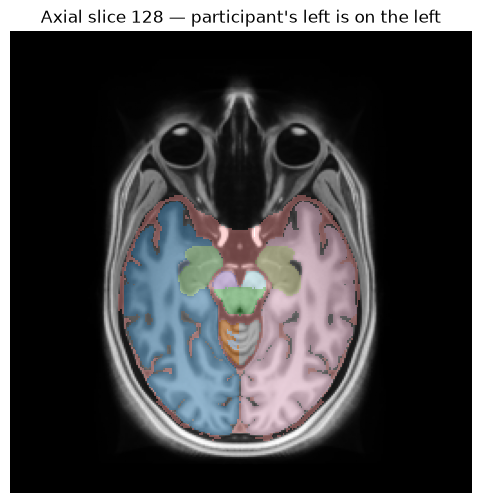

In [33]:
brain = nib.as_closest_canonical(anatomy).get_fdata()
labels = nib.as_closest_canonical(segmentation).get_fdata()
slice_number = brain.shape[2] // 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(brain[:, :, slice_number].T, origin="lower", cmap="gray")
label_slice = np.ma.masked_equal(labels[:, :, slice_number].T, 0)
ax.imshow(label_slice, origin="lower", cmap="tab20", alpha=0.4, interpolation="nearest")
ax.set_title(f"Axial slice {slice_number} — participant's left is on the left")
ax.axis("off")
plt.show()

### Inspect the cortical surfaces

Rotate the pial meshes to look for holes, missing regions or large bulges. This helps find gross defects, but a detached mesh cannot show whether the boundary follows the underlying tissue correctly.

In [34]:
surf_dir = SUBJECT_DIR / "surf"
nv_surf = NiiVue(height=500, is_colorbar=False)
nv_surf.add_mesh(Mesh(path=str(surf_dir / "lh.pial"), rgba255=[255, 90, 90, 255]))
nv_surf.add_mesh(Mesh(path=str(surf_dir / "rh.pial"), rgba255=[90, 90, 255, 255]))
nv_surf

For detailed surface QC, open the anatomy and boundaries together in Freeview. This optional cell opens a desktop window, so it is shown as an example rather than included in Run All:

```python
!freeview -v "{SUBJECT_DIR}/mri/orig.mgz" -f "{surf_dir}/lh.white:edgecolor=blue" "{surf_dir}/lh.pial:edgecolor=red" "{surf_dir}/rh.white:edgecolor=blue" "{surf_dir}/rh.pial:edgecolor=red"
```

The white surface should follow the grey/white boundary, and the pial surface the grey/CSF boundary. Check multiple slices; a few attractive views do not establish that a reconstruction is ready for analysis.

## 6. Read the measurements

### Subcortical volumes

`aseg.stats` is a text file with comments followed by one row per structure. `pd.read_csv` reads whitespace-separated columns; `comment="#"` skips the explanatory header. The column names below follow FreeSurfer's table format.

In [35]:
aseg_columns = [
    "Index", "SegId", "NVoxels", "Volume_mm3", "StructName",
    "normMean", "normStdDev", "normMin", "normMax", "normRange",
]
aseg_table = pd.read_csv(
    SUBJECT_DIR / "stats/aseg.stats", sep=r"\s+", comment="#", names=aseg_columns,
)
aseg_table[["StructName", "Volume_mm3"]].head()

,StructName,Volume_mm3
0,Left-Lateral-Ventricle,8467.1
1,Left-Inf-Lat-Vent,597.3
2,Left-Cerebellum-White-Matter,15661.0
3,Left-Cerebellum-Cortex,46916.3
4,Left-Thalamus,6911.7


Sort by volume to inspect the largest labelled structures. These values can prompt further image review, but they do not tell you whether the boundaries are anatomically accurate.

In [36]:
aseg_table[["StructName", "Volume_mm3", "NVoxels"]].sort_values(
    "Volume_mm3", ascending=False,
).head(12)

,StructName,Volume_mm3,NVoxels
13,CSF,305800.8,304462
21,Right-Cerebellum-Cortex,47400.3,49220
3,Left-Cerebellum-Cortex,46916.3,48827
10,Brain-Stem,20363.3,20593
20,Right-Cerebellum-White-Matter,15896.2,15176
2,Left-Cerebellum-White-Matter,15661.0,14934
0,Left-Lateral-Ventricle,8467.1,8265
18,Right-Lateral-Ventricle,8355.5,8165
4,Left-Thalamus,6911.7,7159
22,Right-Thalamus,6862.8,7128


Whole-brain measures are stored separately in the header. The lines below show brain segmentation volume and estimated intracranial volume (`eTIV`). Head size matters when comparing regional volumes between participants; choosing the appropriate adjustment belongs to the study's analysis plan.

In [37]:
for line in (SUBJECT_DIR / "stats/aseg.stats").read_text().splitlines():
    if line.startswith("# Measure") and (", eTIV," in line or ", BrainSegVol," in line):
        print(line.removeprefix("# Measure "))

BrainSeg, BrainSegVol, Brain Segmentation Volume, 1455275.000000, mm^3
EstimatedTotalIntraCranialVol, eTIV, Estimated Total Intracranial Volume, 1613288.794666, mm^3


### Cortical thickness

Each hemisphere has its own `aparc.stats` file. Read the left hemisphere below; change `hemisphere` to `"rh"` to explore the right. `ThickAvg` is each region's average thickness in millimetres, not a whole-brain mean.

In [38]:
hemisphere = "lh"
cortical_columns = [
    "StructName", "NumVert", "SurfArea", "GrayVol", "ThickAvg",
    "ThickStd", "MeanCurv", "GausCurv", "FoldInd", "CurvInd",
]
cortical_table = pd.read_csv(
    SUBJECT_DIR / "stats" / f"{hemisphere}.aparc.stats",
    sep=r"\s+", comment="#", names=cortical_columns,
)
cortical_table[["StructName", "ThickAvg", "SurfArea", "GrayVol"]].head(10)

,StructName,ThickAvg,SurfArea,GrayVol
0,bankssts,2.512,947,2196
1,caudalanteriorcingulate,2.167,704,1678
2,caudalmiddlefrontal,3.043,2306,7711
3,cuneus,2.267,1639,3932
4,entorhinal,2.534,480,1523
5,fusiform,2.308,2957,7671
6,inferiorparietal,2.685,4556,13763
7,inferiortemporal,2.226,2867,7518
8,isthmuscingulate,2.356,1010,2754
9,lateraloccipital,2.290,5218,12842


Thickness varies with region, age, acquisition and processing. Unexpected values are a reason to revisit the surface placement, not a universal pass/fail test. Remember that this example uses a group-average brain.

### Where to go next

- Use `asegstats2table` and `aparcstats2table` to collect measurements across a cohort.
- Follow the [FreeSurfer tutorials](https://surfer.nmr.mgh.harvard.edu/fswiki/Tutorials) for manual corrections and detailed QC.
- For clinical acquisitions, see [recon-all-clinical](freesurfer-recon-all-clinical.ipynb).
- For projecting fMRI data onto surfaces, see [mri_vol2surf](../functional_imaging/mri_vol2surf.ipynb).

## Dependencies in Jupyter/Python

The watermark records the Python environment used for this notebook. Keep it with the FreeSurfer version printed at the start when sharing your results.

In [39]:
%load_ext watermark
%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get("JUPYTER_IMAGE", "").split(":")[-1]
    or os.environ.get("NEURODESKTOP_VERSION", "unknown")
)
print("Neurodesktop version:", neurodesktop_version)

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2026-09-23T06:52:50.024925+00:00

Python implementation: CPython
Python version       : 3.13.15
IPython version      : 9.17.1

Compiler    : GCC 15.3.0
OS          : Linux
Release     : 7.0.0-28-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

IPython   : 9.17.1
ipyniivue : 2.4.4
json      : 2.0.9
matplotlib: 3.11.2
nibabel   : 5.4.2
numpy     : 2.3.5
pandas    : 3.0.5

Neurodesktop version: 2026-09-22
